In [10]:
# Librerías
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import f_oneway

In [44]:
# Raíz del proyecto y rutas
PROJECT_ROOT = Path().resolve().parents[1]
path = PROJECT_ROOT / "data" / "processed"

# Archivos base
df_model = pd.read_csv(path / "features_intra_anuales_2007-2024.csv", index_col=0)
clusters_mun = pd.read_csv(path / "clusters_municipales.csv")

In [45]:
# Unir al dataset
df_model = df_model.merge(
    clusters_mun,
    on="municipio",
    how="left"
)

# Validación
print(df_model["cluster"].value_counts())

cluster
2    198
1    162
3     54
0     36
Name: count, dtype: int64


In [46]:
df_model.shape

(450, 505)

In [ ]:
# Selección de variables
target = "Rendimiento (t/ha)"

corr = df_model.corr(numeric_only=True)[target].abs().sort_values(ascending=False)

vars_seleccion = corr[corr > 0.14].index.tolist()
vars_seleccion.remove(target)

X = df_model[vars_seleccion]
y = df_model[target]

In [ ]:
# Separación de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Escalado de características
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Modelo Lasso para selección de variables
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

coef = pd.Series(lasso.coef_, index=X.columns)

vars_lasso = coef[coef != 0].sort_values(key=abs, ascending=False)
print(vars_lasso)

produccion_t                       1.283264e-01
temp_mean_z_mean_anual             9.222881e-02
ndvi_mean_min                     -5.985608e-02
ndvi_mean_sum_m04_06              -5.108147e-02
et_potencial_mm_std                4.757853e-02
ndvi_mean_std                     -4.666644e-02
ndvi_min_m12                       4.548664e-02
ndvi_mean_min_m01_06               3.971794e-02
flag_temp_media_alta_p90          -3.427216e-02
et_potencial_mm_m01               -2.803728e-02
precip_max_mm_m08                  2.617241e-02
racha_max_flag_deficit_alto_p90   -2.304492e-02
deficit_hidrico_mm_max_m01_03     -2.283915e-02
ndvi_mean_m05                      2.181217e-02
temp_max_max_m04_06                1.840277e-02
balance_hidrico_mm_min_m01_06     -1.833530e-02
ndvi_mean_min_m01_03              -1.761357e-02
ndvi_min_m01                       1.417764e-02
precip_max_mm_m07                  1.361388e-02
et_real_mm_std                     8.075959e-03
ndvi_mean_m02                      6.282

#### Features de coeficiente diferente (alejadas) de cero (0) son las más relevantes para el modelo
El modelo captura variables lineales

In [18]:
# Modelo Random Forest para selección de varaiables
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias.sort_values(ascending=False).head(20)

produccion_t                     0.275995
ndvi_min_m12                     0.075173
et_potencial_mm_std              0.068227
temp_mean_z_mean_anual           0.051664
temp_mean_z_min_anual            0.044598
ndvi_mean_m05                    0.032951
et_potencial_mm_m01              0.027360
et_real_mm_z_min_anual           0.026773
temp_max_z_max_anual             0.025512
temp_mean_z_max_anual            0.025246
precip_max_mm_m07                0.024992
ndvi_min_m01                     0.024622
precip_max_mm_m08                0.024321
ndvi_mean_m01                    0.020935
ndvi_mean_m08                    0.019095
et_real_mm_std                   0.016976
balance_hidrico_mm_min_m01_06    0.015424
ndvi_mean_std                    0.014398
ndvi_mean_m02                    0.013467
temp_max_z_mean_anual            0.012957
dtype: float64

#### El modelo captura iteraciones y relaciones no lineales

In [29]:
# Intersección de variables seleccionadas por los modelos planteados
vars_rf_top = importancias.sort_values(ascending=False).index
vars_final = list(set(vars_lasso.index) & set(vars_rf_top))
print(f"total de variables seleccionables: {len(vars_final)} \n")
print("Variables seleccionadas :")
vars_final

total de variables seleccionables: 25 

Variables seleccionadas :


['ndvi_mean_min_m01_06',
 'ndvi_mean_m05',
 'flag_temp_media_alta_p90',
 'temp_max_max_m04_06',
 'racha_max_flag_deficit_alto_p90',
 'precip_max_mm_m08',
 'ndvi_mean_min',
 'ndvi_mean_m02',
 'balance_hidrico_mm_min_m01_06',
 'et_real_mm_std',
 'ndvi_mean_sum_m04_06',
 'ndvi_min_m12',
 'ndvi_mean_min_m01_03',
 'produccion_t',
 'deficit_hidrico_mm_max_m01_03',
 'precip_max_mm_m07',
 'ndvi_min_m01',
 'ndvi_mean_mean_m04_06',
 'temp_mean_z_mean_anual',
 'temp_max_mean_m04_06',
 'ndvi_mean_std',
 'et_potencial_mm_m01',
 'exceso_hidrico_mm_m02',
 'et_potencial_mm_std',
 'temp_max_sum_m04_06']

* El NDVI es la señal más fuerte del sistema (dominante). El mejor proxy para del rendimiento
* Señal hídrica clara, el balance hídrico es importante y sus extremos también afectan el rendimiento
* Señal térmica no evidencia señal como tal, pero sí sus anomalías y extremos
* La variabilidad climática aporta información al modelo
* Producción es variable correlacionada con rendimiento - Redundante en el modelo

In [31]:
# Selección sin producción
vars_final = [v for v in vars_final if v != "produccion_t"]

In [32]:
# Agrupaciones estructurales
# NDVI
vars_ndvi = [
    "ndvi_mean_m05",                   # nivel en mes clave
    "ndvi_mean_min_m01_06",            # estrés acumulado
    "ndvi_mean_std",                   # variabilidad
    "ndvi_min_m12"                     # extremo anual
]
# Balance Hídrico
vars_hidrico = [
    "balance_hidrico_mm_min_m01_06",   # peor condición
    "deficit_hidrico_mm_max_m01_03",   # estrés temprano
    "exceso_hidrico_mm_m02",           # exceso puntual
    "racha_max_flag_deficit_alto_p90"  # duración del estrés
]
# Temperatura
vars_termico = [
    "temp_mean_z_mean_anual",          # anomalía general
    "temp_max_max_m04_06",             # extremo crítico
    "flag_temp_media_alta_p90"         # evento extremo
]
# Variabilidad
vars_variabilidad = [
    "et_real_mm_std",
    "et_potencial_mm_std"
]
# Extremos
vars_extremos = [
    "precip_max_mm_m07"                # evento fuerte
]

In [33]:
# Consolidación de variables finales
vars_reducidas = (
    vars_ndvi +
    vars_hidrico +
    vars_termico +
    vars_extremos +
    vars_variabilidad
)

X = df_model[vars_reducidas]
y = df_model["Rendimiento (t/ha)"]

In [35]:
# Modelo explicativo
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

# Validación cruzada
scores = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
print("R2 CV:", scores.mean())

R2 CV: -0.09947395048725696


In [ ]:
# Ajuste al modelo
pipeline.fit(X, y)

coef = pd.Series(
    pipeline.named_steps["model"].coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

print(coef)

temp_mean_z_mean_anual             0.100327
flag_temp_media_alta_p90          -0.057954
et_potencial_mm_std                0.052199
racha_max_flag_deficit_alto_p90   -0.048391
precip_max_mm_m07                  0.043520
deficit_hidrico_mm_max_m01_03     -0.033020
ndvi_min_m12                       0.027533
ndvi_mean_m05                      0.017677
et_real_mm_std                    -0.015400
ndvi_mean_std                     -0.014464
balance_hidrico_mm_min_m01_06     -0.013502
ndvi_mean_min_m01_06              -0.008828
exceso_hidrico_mm_m02             -0.003632
temp_max_max_m04_06               -0.002707
dtype: float64


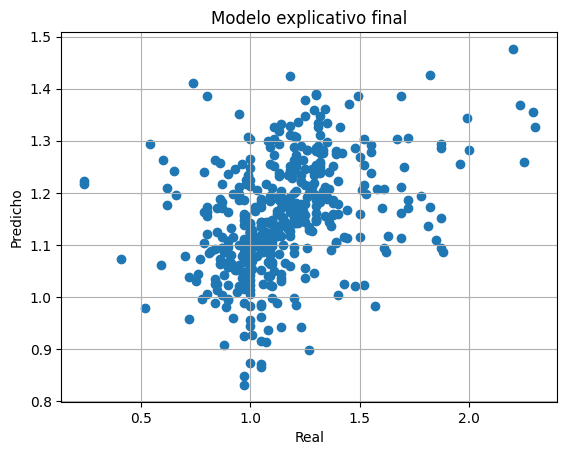

In [37]:
# Validación
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X)

plt.scatter(y, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Modelo explicativo final")
plt.grid()
plt.show()

### El modelo construido no presenta una estructura clara

In [47]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

resultados = {}
coeficientes = {}

for c in sorted(df_model["cluster"].dropna().unique()):
    
    df_c = df_model[df_model["cluster"] == c].copy()
    
    X_c = df_c[vars_reducidas]
    y_c = df_c["Rendimiento (t/ha)"]
    
    # Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])
    
    # Validación cruzada
    scores = cross_val_score(pipeline, X_c, y_c, cv=3, scoring="r2")
    
    resultados[c] = scores.mean()
    
    # Ajuste final para interpretar
    pipeline.fit(X_c, y_c)
    
    coef = pd.Series(
        pipeline.named_steps["model"].coef_,
        index=X_c.columns
    ).sort_values(key=abs, ascending=False)
    
    coeficientes[c] = coef
    
    print(f"\nCluster {c}")
    print(f"R2 CV: {scores.mean():.3f}")
    print(coef.head(8))


Cluster 0
R2 CV: -2.618
flag_temp_media_alta_p90        -0.207031
temp_mean_z_mean_anual           0.151660
balance_hidrico_mm_min_m01_06   -0.087192
ndvi_mean_min_m01_06             0.079133
et_potencial_mm_std              0.074868
deficit_hidrico_mm_max_m01_03   -0.072416
ndvi_mean_m05                   -0.059521
temp_max_max_m04_06             -0.045400
dtype: float64

Cluster 1
R2 CV: -0.429
temp_mean_z_mean_anual             0.109744
et_potencial_mm_std                0.090070
racha_max_flag_deficit_alto_p90   -0.081106
et_real_mm_std                    -0.072144
ndvi_mean_m05                      0.058499
exceso_hidrico_mm_m02              0.050106
temp_max_max_m04_06                0.040884
flag_temp_media_alta_p90          -0.034253
dtype: float64

Cluster 2
R2 CV: -0.522
precip_max_mm_m07                0.067459
temp_mean_z_mean_anual           0.059660
ndvi_mean_std                    0.057987
ndvi_min_m12                     0.052006
flag_temp_media_alta_p90        -0.0508

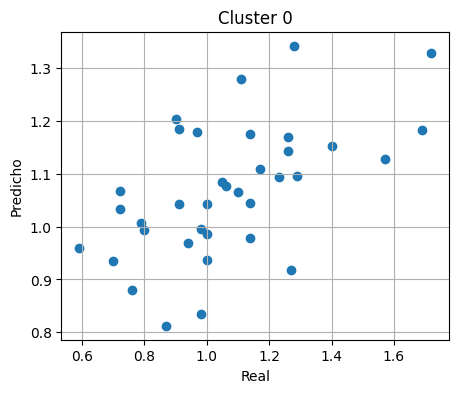

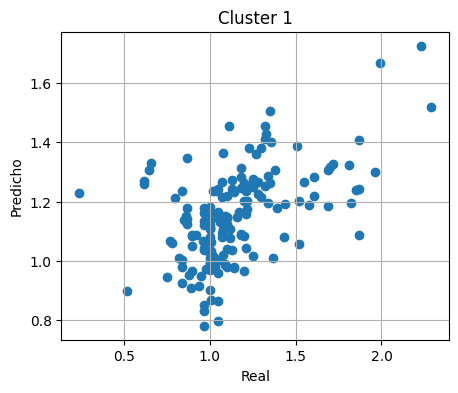

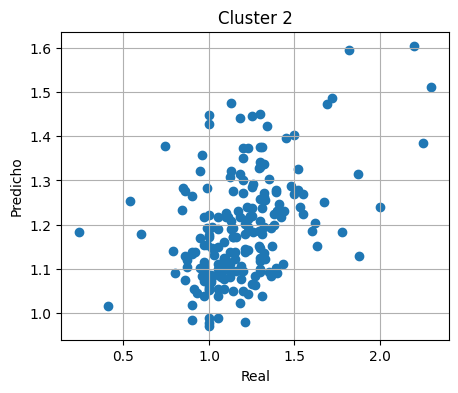

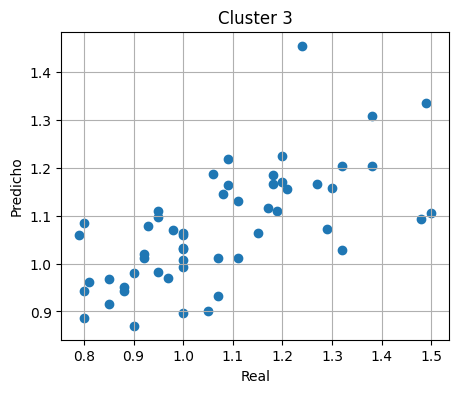

In [48]:
import matplotlib.pyplot as plt

for c in sorted(df_model["cluster"].dropna().unique()):
    
    df_c = df_model[df_model["cluster"] == c]
    
    X_c = df_c[vars_reducidas]
    y_c = df_c["Rendimiento (t/ha)"]
    
    pipeline.fit(X_c, y_c)
    y_pred = pipeline.predict(X_c)
    
    plt.figure(figsize=(5,4))
    plt.scatter(y_c, y_pred)
    plt.title(f"Cluster {c}")
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.grid()
    plt.show()

In [ ]:
# ejemplo: usar solo top 8 variables por cluster
vars_cluster = coef.head(8).index.tolist()

['et_real_mm_std',
 'et_potencial_mm_std',
 'ndvi_mean_m05',
 'exceso_hidrico_mm_m02',
 'temp_max_max_m04_06',
 'balance_hidrico_mm_min_m01_06',
 'ndvi_mean_min_m01_06',
 'precip_max_mm_m07']